In [56]:
#POOLED PCA

In [60]:
#packages
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import glob

In [61]:
#COMBINE DATASETS OF ALL THE STABLECOINS
files = glob.glob("clean_data/*_final.parquet")

df_list = []
for file in files:
    temp = pd.read_parquet(file)
    coin_name = file.split("/")[-1].replace(".parquet", "").replace("_final", "")
    temp["coin"] = coin_name
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,Unnamed: 0,depeg,depeg_future_1d,depeg_future_3d,depeg_future_5d,depeg_future_7d,depeg_future_14d,depeg_future_30d,symbol,timestamp,...,peg_error,abs_peg_error,price_deviation_5d,price_deviation_30d,downward_price_deviation_5d,downward_price_deviation_30d,fear_greed_index,fear_greed_index_category,fed_funds_rate,coin
0,30.0,0,0,0,0,0,0,0,UST,2020-12-25 23:59:59,...,-0.001375,0.001375,0.002765,0.001560,0.002765,0.001541,94.0,Extreme Greed,0.09,ust
1,31.0,0,0,0,0,0,0,0,UST,2020-12-26 23:59:59,...,-0.002121,0.002121,0.002795,0.001605,0.002795,0.001589,93.0,Extreme Greed,0.09,ust
2,32.0,0,0,0,0,0,0,0,UST,2020-12-27 23:59:59,...,-0.000279,0.000279,0.002279,0.001604,0.002279,0.001587,91.0,Extreme Greed,0.09,ust
3,33.0,0,0,0,0,0,0,0,UST,2020-12-28 23:59:59,...,-0.001755,0.001755,0.002359,0.001631,0.002359,0.001615,92.0,Extreme Greed,0.09,ust
4,34.0,0,1,1,1,1,1,1,UST,2020-12-29 23:59:59,...,-0.002543,0.002543,0.001790,0.001694,0.001790,0.001679,91.0,Extreme Greed,0.09,ust


In [62]:
#split 

POOLED_SPLIT_DATE = "2022-06-30"

def split_by_date(df, split_date, date_col="timestamp"):
    df = df.sort_values(date_col).reset_index(drop=True).copy()
    split_date = pd.Timestamp(split_date)
    train = df[df[date_col] <= split_date].copy()
    test  = df[df[date_col] > split_date].copy()
    return train, test

df_train, df_test = split_by_date(df, POOLED_SPLIT_DATE)   # df is already pooled

print(df_train.shape, df_test.shape)
print(df_train["coin"].value_counts())
print(df_test["coin"].value_counts())

(2710, 44) (5436, 44)
usdc    552
dai     552
usdt    552
pax     552
ust     502
Name: coin, dtype: int64
dai     1359
usdc    1359
pax     1359
usdt    1359
Name: coin, dtype: int64


In [63]:
#check columns
print(df.columns)

Index(['Unnamed: 0', 'depeg', 'depeg_future_1d', 'depeg_future_3d',
       'depeg_future_5d', 'depeg_future_7d', 'depeg_future_14d',
       'depeg_future_30d', 'symbol', 'timestamp', 'timeOpen', 'timeClose',
       'timeHigh', 'timeLow', 'open', 'high', 'low', 'close', 'volume',
       'marketCap', 'circulatingSupply', 'percent_change_24h',
       'percent_change_7d', 'percent_change_30d', 'volume_percent_change_24h',
       'volume_percent_change_7d', 'volume_percent_change_30d',
       'market_cap_percent_change_24h', 'market_cap_percent_change_7d',
       'market_cap_percent_change_30d',
       'circulating_supply_percent_change_24h',
       'circulating_supply_percent_change_7d',
       'circulating_supply_percent_change_30d', 'realized_daily_volatility',
       'peg_error', 'abs_peg_error', 'price_deviation_5d',
       'price_deviation_30d', 'downward_price_deviation_5d',
       'downward_price_deviation_30d', 'fear_greed_index',
       'fear_greed_index_category', 'fed_funds_rate

In [64]:
features = [
    'percent_change_24h', 'percent_change_7d', 'percent_change_30d',
    'volume_percent_change_24h', 'volume_percent_change_7d', 'volume_percent_change_30d',
    'market_cap_percent_change_24h', 'market_cap_percent_change_7d', 'market_cap_percent_change_30d',
    'circulating_supply_percent_change_24h', 'circulating_supply_percent_change_7d',
    'circulating_supply_percent_change_30d',
    'realized_daily_volatility',
    'fear_greed_index', 'fed_funds_rate'
]

In [65]:
#global scaler
scaler = StandardScaler()
X_train_normalized = pd.DataFrame(
    scaler.fit_transform(df_train[features].fillna(0)),
    index=df_train.index,
    columns=features
)
X_test_normalized = pd.DataFrame(
    scaler.transform(df_test[features].fillna(0)),
    index=df_test.index,
    columns=features
)

# reconstruction error
X_train_recon = pca.inverse_transform(pca.transform(X_train))
X_test_recon  = pca.inverse_transform(pca.transform(X_test))

df_train['recon_error'] = np.mean((X_train.values - X_train_recon) ** 2, axis=1)
df_test['recon_error']  = np.mean((X_test.values  - X_test_recon)  ** 2, axis=1)

In [66]:
# Per-coin threshold
THRESHOLD_PERCENTILE = 0.99

thresholds = (
    df_train.groupby('coin')['recon_error']
    .quantile(THRESHOLD_PERCENTILE)
    .to_dict()
)

df_test['threshold'] = df_test['coin'].map(thresholds)
df_test['anomaly']   = (df_test['recon_error'] > df_test['threshold']).astype(int)

In [67]:
# checking best percentile (for above threshold)
for p in [0.95, 0.97, 0.99, 0.995]:
    thresholds = df_train.groupby('coin')['recon_error'].quantile(p).to_dict()
    df_test['anomaly'] = (df_test['recon_error'] > df_test['coin'].map(thresholds)).astype(int)
    precision_avg = df_test.groupby('coin').apply(
        lambda g: precision_score(g['depeg_future_3d'], g['anomaly'], zero_division=0)
    ).mean()
    recall_avg = df_test.groupby('coin').apply(
        lambda g: recall_score(g['depeg_future_3d'], g['anomaly'], zero_division=0)
    ).mean()
    print(f"p={p}  avg_precision={precision_avg:.4f}  avg_recall={recall_avg:.4f}")

p=0.95  avg_precision=0.0251  avg_recall=0.7987
p=0.97  avg_precision=0.0269  avg_recall=0.7651
p=0.99  avg_precision=0.0394  avg_recall=0.6793
p=0.995  avg_precision=0.0378  avg_recall=0.6077


In [68]:
def clean_features(df, features):
    df = df.copy()
    # Replace inf/-inf with NaN first
    df[features] = df[features].replace([np.inf, -np.inf], np.nan)

    # Fill NaN per coin per feature (forward fill, then backward fill, then 0)
    df[features] = (
        df.groupby('coin')[features]
        .transform(lambda x: x.ffill().bfill())
        .fillna(0)
    )
    return df

df_train = clean_features(df_train, features)
df_test = clean_features(df_test, features)

# Sanity check — should print nothing if clean
for col in features:
    bad = (~np.isfinite(df_train[col])).sum()
    if bad > 0:
        print(f"train {col}: {bad} bad values remaining")

for col in features:
    bad = (~np.isfinite(df_test[col])).sum()
    if bad > 0:
        print(f"test {col}: {bad} bad values remaining")

In [69]:
# PCA on training set
n_components = 10  # tune as needed
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_normalized)
X_test_pca = pca.transform(X_test_normalized)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

# Reconstruction error
X_train_recon = pca.inverse_transform(X_train_pca)
df_train['recon_error'] = np.mean((X_train_normalized.values - X_train_recon)**2, axis=1)

X_test_recon = pca.inverse_transform(X_test_pca)
df_test['recon_error'] = np.mean((X_test_normalized.values - X_test_recon)**2, axis=1)

# Per-coin thresholds 
THRESHOLD_QUANTILE = 0.99 # tune as required to check for anomalies

thresholds = {}
for coin, group in df_train.groupby('coin'):
    thresholds[coin] = group['recon_error'].quantile(THRESHOLD_QUANTILE)

Explained variance ratio: [0.25595054 0.15452006 0.12457817 0.1089558  0.07177747 0.06419477
 0.05617474 0.05074992 0.03816265 0.03539893]
Cumulative: [0.25595054 0.41047061 0.53504878 0.64400458 0.71578204 0.77997681
 0.83615155 0.88690147 0.92506412 0.96046305]


In [70]:
results = []

for coin, group in df_test.groupby('coin'):
    y_true = group['depeg_future_3d'].astype(bool)
    y_pred = group['anomaly']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, group['recon_error'])
    except ValueError:
        auc = np.nan  # only one class present

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append({
        'coin': coin,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'specificity': round(specificity, 4),
        'auc_roc': round(auc, 4) if not np.isnan(auc) else np.nan,
        'n_anomalies': y_pred.sum(),
        'n_true_depegs': y_true.sum(),
        'threshold': round(thresholds.get(coin, np.nan), 6)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

coin  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai     0.0214  0.7500 0.0417       0.8989   0.9489          140              4   0.165589
 pax     0.1014  0.0854 0.0927       0.9514   0.5767           69             82   0.910981
usdc     0.0058  0.6667 0.0115       0.2356   0.5374         1038              9   0.054122
usdt     0.0226  0.9286 0.0442       0.1563   0.5533         1149             28   0.033686


In [71]:
results = []

for coin, group in df_test.groupby('coin'):
    y_true = group['depeg_future_7d'].astype(bool)
    y_pred = group['anomaly']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, group['recon_error'])
    except ValueError:
        auc = np.nan  # only one class present

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append({
        'coin': coin,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'specificity': round(specificity, 4),
        'auc_roc': round(auc, 4) if not np.isnan(auc) else np.nan,
        'n_anomalies': y_pred.sum(),
        'n_true_depegs': y_true.sum(),
        'threshold': round(thresholds.get(coin, np.nan), 6)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

coin  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai     0.0286  0.5000 0.0541       0.8993   0.7770          140              8   0.165589
 pax     0.2464  0.1062 0.1485       0.9566   0.6080           69            160   0.910981
usdc     0.0135  0.8235 0.0265       0.2370   0.5751         1038             17   0.054122
usdt     0.0357  0.7885 0.0683       0.1523   0.4602         1149             52   0.033686


In [72]:
results = []

for coin, group in df_test.groupby('coin'):
    y_true = group['depeg_future_14d'].astype(bool)
    y_pred = group['anomaly']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, group['recon_error'])
    except ValueError:
        auc = np.nan  # only one class present

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append({
        'coin': coin,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'specificity': round(specificity, 4),
        'auc_roc': round(auc, 4) if not np.isnan(auc) else np.nan,
        'n_anomalies': y_pred.sum(),
        'n_true_depegs': y_true.sum(),
        'threshold': round(thresholds.get(coin, np.nan), 6)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

coin  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai     0.0357  0.3333 0.0645       0.8996   0.5692          140             15   0.165589
 pax     0.3623  0.0929 0.1479       0.9596   0.6310           69            269   0.910981
usdc     0.0193  0.8333 0.0377       0.2375   0.5182         1038             24   0.054122
usdt     0.0627  0.7660 0.1158       0.1486   0.4301         1149             94   0.033686


In [73]:
results = []

for coin, group in df_test.groupby('coin'):
    y_true = group['depeg_future_1d'].astype(bool)
    y_pred = group['anomaly']

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, group['recon_error'])
    except ValueError:
        auc = np.nan  # only one class present

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    results.append({
        'coin': coin,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'f1': round(f1, 4),
        'specificity': round(specificity, 4),
        'auc_roc': round(auc, 4) if not np.isnan(auc) else np.nan,
        'n_anomalies': y_pred.sum(),
        'n_true_depegs': y_true.sum(),
        'threshold': round(thresholds.get(coin, np.nan), 6)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

coin  precision  recall     f1  specificity  auc_roc  n_anomalies  n_true_depegs  threshold
 dai     0.0071  0.5000 0.0141       0.8976   0.9315          140              2   0.165589
 pax     0.0435  0.0968 0.0600       0.9503   0.6346           69             31   0.910981
usdc     0.0039  0.8000 0.0077       0.2363   0.6248         1038              5   0.054122
usdt     0.0131  0.9375 0.0258       0.1556   0.6018         1149             16   0.033686


      sum      mean
coin               
dai    55  0.099638
pax     8  0.014493
usdc   64  0.115942
usdt   28  0.050725
ust    59  0.117530
      sum      mean
coin               
dai     4  0.002943
pax    82  0.060338
usdc    9  0.006623
usdt   28  0.020603


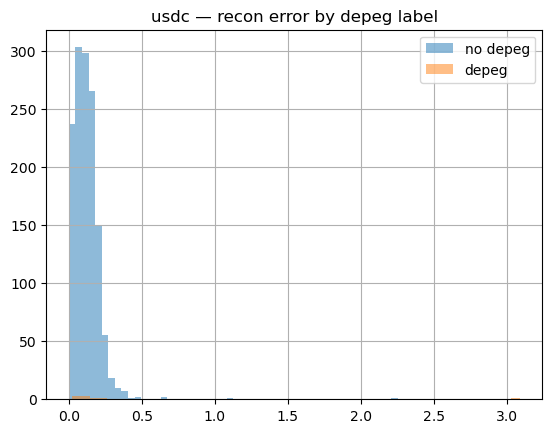

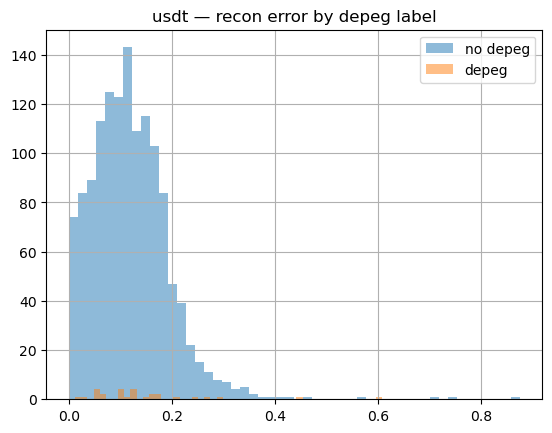

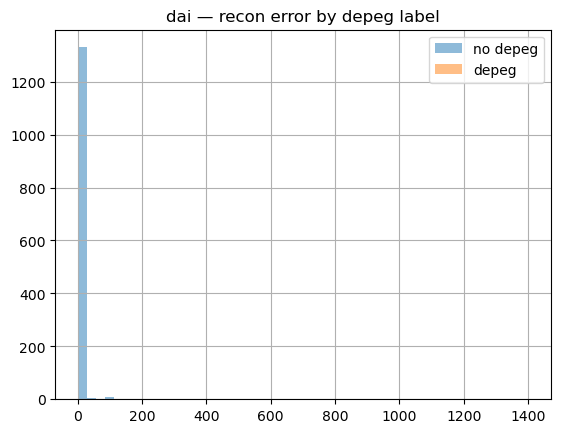

In [59]:
#Checking depegs USDC/USDT in train vs test
print(df_train.groupby('coin')['depeg_future_3d'].agg(['sum', 'mean']))
print(df_test.groupby('coin')['depeg_future_3d'].agg(['sum', 'mean']))

# recon error distribution
import matplotlib.pyplot as plt

for coin in ['usdc', 'usdt', 'dai']:
    subset = df_test[df_test['coin'] == coin]
    fig, ax = plt.subplots()
    subset[subset['depeg_future_3d'] == 0]['recon_error'].hist(
        bins=50, alpha=0.5, label='no depeg', ax=ax)
    subset[subset['depeg_future_3d'] == 1]['recon_error'].hist(
        bins=50, alpha=0.5, label='depeg', ax=ax)
    ax.set_title(f'{coin} — recon error by depeg label')
    ax.legend()
    plt.show()